<a href="https://colab.research.google.com/github/chitra1003/DAA-LAB/blob/main/DAA_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

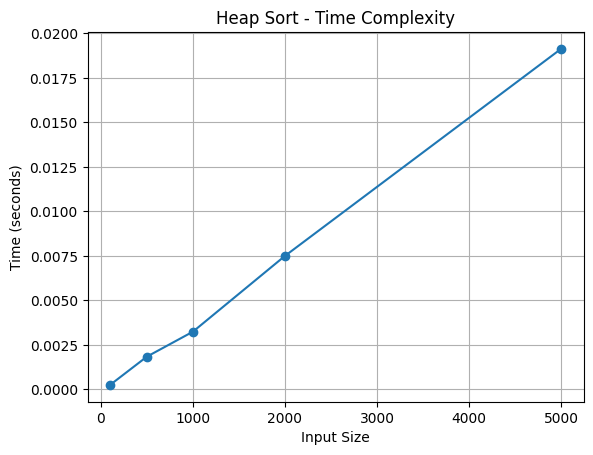

In [1]:
import time
import random
import matplotlib.pyplot as plt

def heapify(a, n, i):
    largest = i
    l, r = 2*i+1, 2*i+2

    if l < n and a[l] > a[largest]:
        largest = l
    if r < n and a[r] > a[largest]:
        largest = r

    if largest != i:
        a[i], a[largest] = a[largest], a[i]
        heapify(a, n, largest)

def heap_sort(a):
    n = len(a)

    for i in range(n//2-1, -1, -1):
        heapify(a, n, i)

    for i in range(n-1, 0, -1):
        a[0], a[i] = a[i], a[0]
        heapify(a, i, 0)

sizes = [100, 500, 1000, 2000, 5000]
times = []

for n in sizes:
    a = [random.randint(1, n) for _ in range(n)]

    start = time.time()
    heap_sort(a)
    times.append(time.time() - start)

plt.plot(sizes, times, marker='o')
plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("Heap Sort - Time Complexity")
plt.grid()
plt.show()

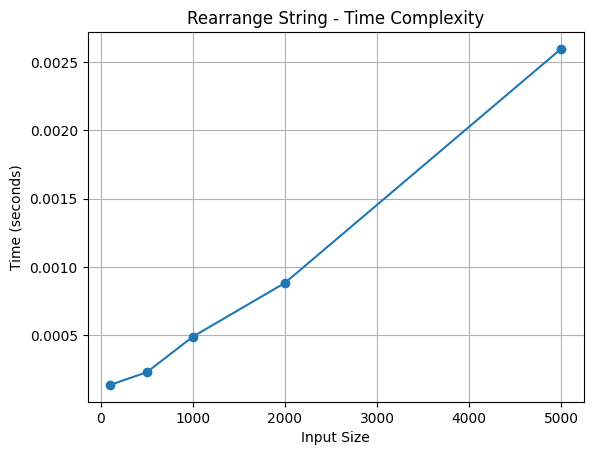

In [2]:
import time
import random
import matplotlib.pyplot as plt
import heapq
from collections import Counter

def rearrange(s):
    freq = Counter(s)
    heap = [(-v, k) for k, v in freq.items()]
    heapq.heapify(heap)

    ans = []
    prev = (0, '')

    while heap:
        count, ch = heapq.heappop(heap)
        ans.append(ch)

        if prev[0] < 0:
            heapq.heappush(heap, prev)

        count += 1
        prev = (count, ch)

    return ''.join(ans)

sizes = [100, 500, 1000, 2000, 5000]
times = []

for n in sizes:
    s = ''.join(random.choice("abcde") for _ in range(n))

    start = time.time()
    rearrange(s)
    times.append(time.time() - start)

plt.plot(sizes, times, marker='o')
plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("Rearrange String - Time Complexity")
plt.grid()
plt.show()

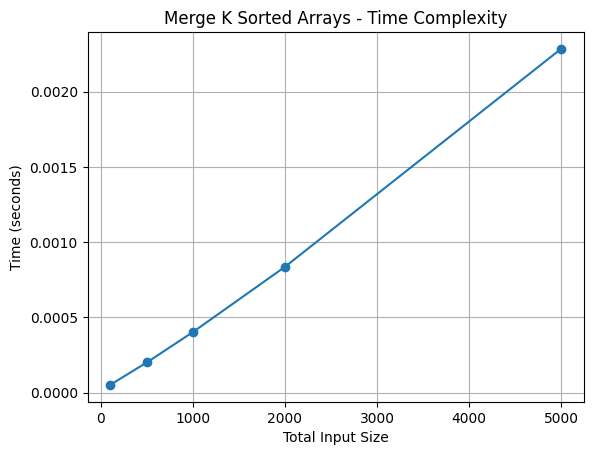

In [4]:
import time
import random
import heapq
import matplotlib.pyplot as plt

def merge(arrays):
    heap = []
    result = []

    for i in range(len(arrays)):
        if arrays[i]:
            heapq.heappush(heap, (arrays[i][0], i, 0))

    while heap:
        val, i, j = heapq.heappop(heap)
        result.append(val)

        if j + 1 < len(arrays[i]):
            heapq.heappush(heap, (arrays[i][j+1], i, j+1))

    return result

sizes = [100, 500, 1000, 2000, 5000]
times = []

for n in sizes:
    arrays = []

    for i in range(5):
        arr = sorted([random.randint(1, n) for _ in range(n//5)])
        arrays.append(arr)

    start = time.time()
    merge(arrays)
    times.append(time.time() - start)

plt.plot(sizes, times, marker='o')
plt.xlabel("Total Input Size")
plt.ylabel("Time (seconds)")
plt.title("Merge K Sorted Arrays - Time Complexity")
plt.grid()
plt.show()

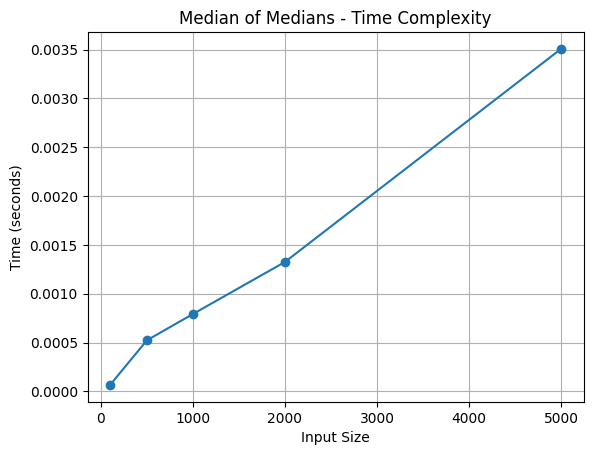

In [5]:
import time
import random
import matplotlib.pyplot as plt

def mom(a, k):
    if len(a) <= 5:
        return sorted(a)[k-1]

    groups = [a[i:i+5] for i in range(0, len(a), 5)]
    medians = [sorted(g)[len(g)//2] for g in groups]

    pivot = mom(medians, (len(medians)+1)//2)

    low = [x for x in a if x < pivot]
    equal = [x for x in a if x == pivot]
    high = [x for x in a if x > pivot]

    if k <= len(low):
        return mom(low, k)
    elif k <= len(low) + len(equal):
        return pivot
    else:
        return mom(high, k-len(low)-len(equal))

sizes = [100, 500, 1000, 2000, 5000]
times = []

for n in sizes:
    a = [random.randint(1, n) for _ in range(n)]

    start = time.time()
    mom(a, n//2)
    times.append(time.time() - start)

plt.plot(sizes, times, marker='o')
plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("Median of Medians - Time Complexity")
plt.grid()
plt.show()